# Python Seminar No.4

特徴量エンジニアリングを使ってLasso回帰を行います。

## 1. ライブラリの読み込み

まず、データの読み込み、計算、機械学習、評価に使うライブラリを読み込みます。

In [83]:
# 数値計算をするためのライブラリを読み込みます。
import numpy as np

# 表形式のデータを扱うためのライブラリを読み込みます。
import pandas as pd

# データを学習用とテスト用に分ける道具を読み込みます。
from sklearn.model_selection import train_test_split

# 特徴量の大きさをそろえる道具を読み込みます。
from sklearn.preprocessing import StandardScaler

# Lasso回帰を自動調整しながら学習するモデルを読み込みます。
from sklearn.linear_model import LassoCV

# モデルの予測精度を評価する道具を読み込みます。
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# グラフを描くためのライブラリを読み込みます。
import matplotlib.pyplot as plt

## 2. CSVファイルの読み込み

`pd.read_csv()` を使ってCSVファイルを読み込み、先頭5行を表示して中身を確認します。

In [84]:
# 読み込むCSVファイルの場所を指定します。
file_path = "/Users/k-teppei/Documents/Python Seminar/feature_engineering_dataset.csv"

# CSVファイルを読み込んで、dfという名前の表にします。
df = pd.read_csv(file_path)

# データの先頭5行を表示して、内容を確認します。
df.head()

,x1,x2,x3,x4,y
0,-1.254599,-3.148671,-2.382943,1.727030,4.474510
1,4.507143,0.419009,-2.530212,2.966814,16.006309
2,2.319939,3.729458,4.062546,-2.495321,-1.629434
3,0.986585,2.322249,-2.504538,1.248741,1.787929
4,-3.439814,3.065611,-2.280503,0.717460,5.071840


## 3. 説明変数と目的変数に分ける

`x1` から `x4` は予測に使う説明変数、`y` は予測したい目的変数として分けます。

In [85]:
# 予測に使う列の名前をリストにまとめます。
feature_columns = ["x1", "x2", "x3", "x4"]

# x1からx4を説明変数Xとして取り出します。
X = df[feature_columns]

# yを予測したい目的変数として取り出します。
y = df["y"]

# 説明変数のデータ数と列数を確認します。
print("説明変数の形:", X.shape)

# 目的変数のデータ数を確認します。
print("目的変数の形:", y.shape)

説明変数の形: (1000, 4)
目的変数の形: (1000,)


## 4. 二乗・三乗した特徴量を作る

元の特徴量だけでなく、各特徴量を二乗・三乗した列を追加します。これにより、直線だけでは表しにくい関係も学習しやすくなります。

In [86]:
# 元の説明変数をコピーして、新しい特徴量を追加する表を作ります。
X_engineered = X.copy()

# 各特徴量について、二乗と三乗の列を追加します。
for column in feature_columns:
    # 例: x1を二乗したx1_squaredという列を作ります。
    X_engineered[f"{column}_squared"] = X[column] ** 2

    # 例: x1を三乗したx1_cubedという列を作ります。
    X_engineered[f"{column}_cubed"] = X[column] ** 3

# 新しく作った特徴量を含むデータを確認します。
X_engineered.head()

,x1,x2,x3,x4,x1_squared,x1_cubed,x2_squared,x2_cubed,x3_squared,x3_cubed,x4_squared,x4_cubed
0,-1.254599,-3.148671,-2.382943,1.727030,1.574018,-1.974761,9.914127,-31.216322,5.678418,-13.531348,2.982632,5.151095
1,4.507143,0.419009,-2.530212,2.966814,20.314339,91.559630,0.175569,0.073565,6.401973,-16.198348,8.801985,26.113853
2,2.319939,3.729458,4.062546,-2.495321,5.382119,12.486190,13.908860,51.872513,16.504278,67.049387,6.226627,-15.537433
3,0.986585,2.322249,-2.504538,1.248741,0.973350,0.960292,5.392840,12.523516,6.272711,-15.710242,1.559354,1.947229
4,-3.439814,3.065611,-2.280503,0.717460,11.832318,-40.700967,9.397974,28.810536,5.200693,-11.860194,0.514749,0.369311


## 5. 学習用データとテスト用データに分ける

モデルを作るための学習用データと、モデルの性能を確認するためのテスト用データに分けます。

In [87]:
# データの80%を学習用、20%をテスト用に分けます。
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered,
    y,
    test_size=0.2,
    random_state=42
)

# 学習用データの大きさを確認します。
print("学習用データ:", X_train.shape)

# テスト用データの大きさを確認します。
print("テスト用データ:", X_test.shape)

学習用データ: (800, 12)
テスト用データ: (200, 12)


## 6. 特徴量のスケールをそろえる

Lasso回帰は特徴量の大きさの影響を受けやすいため、平均0・標準偏差1になるように変換します。

In [88]:
# 特徴量の大きさをそろえるための変換器を作ります。
scaler = StandardScaler()

# 学習用データから平均と標準偏差を計算し、標準化します。
X_train_scaled = scaler.fit_transform(X_train)

# テスト用データも、学習用データと同じ基準で標準化します。
X_test_scaled = scaler.transform(X_test)

## 7. Lasso回帰モデルを学習する

`LassoCV` は、Lasso回帰で重要な `alpha` という値を自動で選びながら学習してくれます。

In [89]:
# Lasso回帰モデルを作ります。cv=5はデータを5分割して良いalphaを探す設定です。
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)

# 標準化した学習用データを使って、モデルを学習させます。
lasso.fit(X_train_scaled, y_train)

# モデルが自動で選んだalphaの値を表示します。
print("選ばれたalpha:", lasso.alpha_)

選ばれたalpha: 0.06045500282545656


## 8. テストデータで予測する

学習済みのモデルを使って、まだ学習に使っていないテストデータの `y` を予測します。

In [90]:
# 学習済みモデルを使って、訓練データのyを予測します。
y_train_pred = lasso.predict(X_train_scaled)

# 学習済みモデルを使って、テストデータのyを予測します。
y_pred = lasso.predict(X_test_scaled)

# テストデータの実際の値と予測値を並べた表を作ります。
result_df = pd.DataFrame({
    "実際の値": y_test.values,
    "予測値": y_pred
})

# 予測結果の先頭5行を表示します。
result_df.head()

,実際の値,予測値
0,0.536017,0.728857
1,10.184375,8.145622
2,14.151438,13.170673
3,0.240240,1.059068
4,1.811849,0.090938


## 9. グラフで予測結果を確認する

実際の値と予測値を散布図で比較します。点が斜めの線に近いほど、予測がよく合っています。

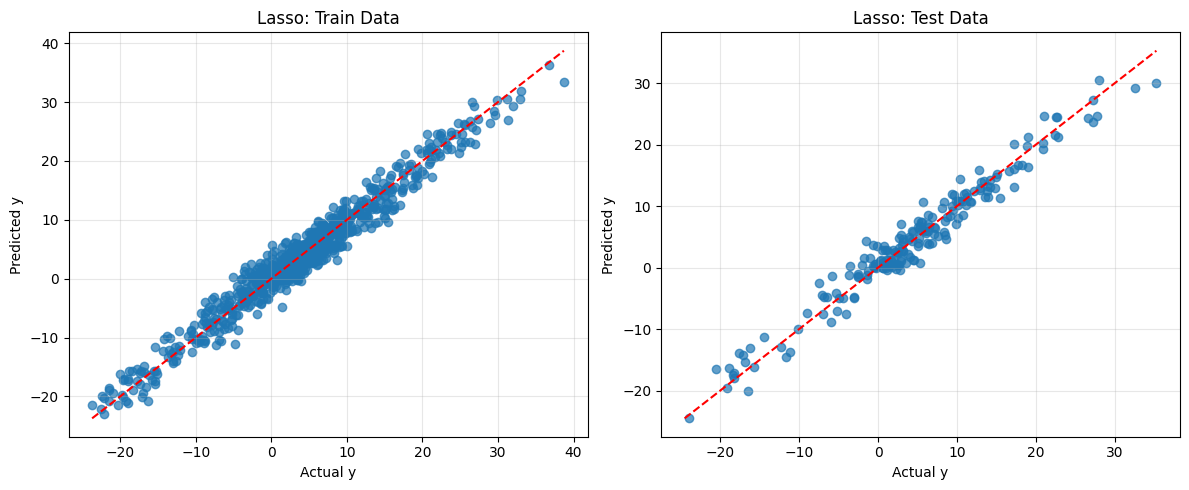

In [91]:
# 訓練データとテストデータのグラフを横に並べて表示します。
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 訓練データの実際の値と予測値を点で描きます。
axes[0].scatter(y_train, y_train_pred, alpha=0.7)

# 訓練データで、実際の値と予測値が一致する基準線を描きます。
train_min_value = min(y_train.min(), y_train_pred.min())
train_max_value = max(y_train.max(), y_train_pred.max())
axes[0].plot([train_min_value, train_max_value], [train_min_value, train_max_value], color="red", linestyle="--")

# 訓練データのグラフタイトルと軸ラベルを設定します。
axes[0].set_title("Lasso: Train Data")
axes[0].set_xlabel("Actual y")
axes[0].set_ylabel("Predicted y")
axes[0].grid(True, alpha=0.3)

# テストデータの実際の値と予測値を点で描きます。
axes[1].scatter(y_test, y_pred, alpha=0.7)

# テストデータで、実際の値と予測値が一致する基準線を描きます。
test_min_value = min(y_test.min(), y_pred.min())
test_max_value = max(y_test.max(), y_pred.max())
axes[1].plot([test_min_value, test_max_value], [test_min_value, test_max_value], color="red", linestyle="--")

# テストデータのグラフタイトルと軸ラベルを設定します。
axes[1].set_title("Lasso: Test Data")
axes[1].set_xlabel("Actual y")
axes[1].set_ylabel("Predicted y")
axes[1].grid(True, alpha=0.3)

# グラフ同士が重ならないように間隔を調整します。
plt.tight_layout()

# グラフを表示します。
plt.show()

## 10. モデルの性能を確認する

`R2` は1に近いほど良く、`RMSE` と `MAE` は小さいほど予測誤差が小さいことを表します。

In [92]:
# R2を計算します。1に近いほど、モデルの当てはまりが良いです。
r2 = r2_score(y_test, y_pred)

# RMSEを計算します。予測のずれの大きさを表し、小さいほど良いです。
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAEを計算します。平均でどれくらい予測が外れたかを表します。
mae = mean_absolute_error(y_test, y_pred)

# R2を表示します。
print("R2:", r2)

# RMSEを表示します。
print("RMSE:", rmse)

# MAEを表示します。
print("MAE:", mae)

R2: 0.9600704966958347
RMSE: 2.058836440722508
MAE: 1.6318271367987551


## 11. どの特徴量が使われたか確認する

Lasso回帰では、重要でない特徴量の係数が0になりやすいです。係数を見ることで、どの特徴量が予測に効いているかを確認できます。

In [93]:
# 特徴量名とLasso回帰の係数を表にまとめます。
coef_df = pd.DataFrame({
    "特徴量": X_engineered.columns,
    "係数": lasso.coef_
})

# 係数の大きさを比べやすくするため、絶対値の列を作ります。
coef_df["係数の絶対値"] = coef_df["係数"].abs()

# 係数の絶対値が大きい順に並べて、重要そうな特徴量を確認します。
coef_df.sort_values("係数の絶対値", ascending=False)

,特徴量,係数,係数の絶対値
11,x4_cubed,9.167352,9.167352
4,x1_squared,3.688570,3.688570
0,x1,-0.000000,0.000000
1,x2,-0.000000,0.000000
2,x3,0.000000,0.000000
3,x4,0.000000,0.000000
5,x1_cubed,-0.000000,0.000000
6,x2_squared,-0.000000,0.000000
7,x2_cubed,-0.000000,0.000000
8,x3_squared,-0.000000,0.000000


# 課題2: SVRで材料寿命を予測する

`Material_Lifespan_Dataset_encoded_sklearn.csv` を使って、`PredictedHours` を予測するSVRモデルを作ります。

## 1. ライブラリの読み込み

SVRモデル、データ分割、標準化、評価に必要なライブラリを読み込みます。

In [94]:
# 表形式のデータを扱うためのライブラリを読み込みます。
import pandas as pd

# 数値計算をするためのライブラリを読み込みます。
import numpy as np

# データを学習用とテスト用に分ける道具を読み込みます。
from sklearn.model_selection import GridSearchCV, train_test_split

# 特徴量の大きさをそろえる道具を読み込みます。
from sklearn.preprocessing import StandardScaler

# SVRという回帰モデルを読み込みます。
from sklearn.svm import SVR

# モデルの予測精度を評価する道具を読み込みます。
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# グラフを描くためのライブラリを読み込みます。
import matplotlib.pyplot as plt

## 2. CSVファイルの読み込み

材料寿命データのCSVファイルを読み込み、先頭5行を表示して中身を確認します。

In [95]:
# 読み込むCSVファイルの場所を指定します。
material_file_path = "/Users/k-teppei/Documents/Python Seminar/Material_Lifespan_Dataset_encoded_sklearn.csv"

# CSVファイルを読み込んで、material_dfという名前の表にします。
material_df = pd.read_csv(material_file_path)

# データの先頭5行を表示して、内容を確認します。
material_df.head()

,PredictedHours,CoolRate,QuenchDuration,ForgeDuration,HeatProcessTime,NickelComposition,IronComposition,CobaltComposition,ChromiumComposition,MinorDefects,...,ComponentType_Nozzle,ComponentType_Valve,StructureType_colGrain,StructureType_equiGrain,StructureType_singleGrain,InitialPosition_Bottom,InitialPosition_Top,FormationMethod_Continuous,FormationMethod_Die,FormationMethod_Investment
0,1461.797,12.836,3.803,6.515,47.005,65.450,16.618,16.510,0.938,10,...,1,0,0,1,0,1,0,0,1,0
1,1825.977,19.032,2.593,3.521,45.246,54.162,34.916,6.063,4.292,19,...,0,0,0,0,1,1,0,0,0,1
2,707.101,28.418,0.772,1.327,9.639,52.565,36.486,8.927,3.355,35,...,0,0,0,1,0,1,0,0,0,1
3,1086.370,9.084,1.990,2.201,20.009,56.665,23.436,17.040,2.827,0,...,1,0,1,0,0,0,1,1,0,0
4,1813.529,16.196,4.092,3.881,15.904,60.502,26.995,11.382,1.564,10,...,0,0,1,0,0,0,1,0,1,0


## 3. 説明変数と目的変数に分ける

`PredictedHours` が予測したい材料寿命です。それ以外の列を予測に使う説明変数にします。

In [96]:
# PredictedHours以外の列を説明変数Xにします。
material_X = material_df.drop("PredictedHours", axis=1)

# PredictedHoursを予測したい目的変数yにします。
material_y = material_df["PredictedHours"]

# 説明変数のデータ数と列数を確認します。
print("説明変数の形:", material_X.shape)

# 目的変数のデータ数を確認します。
print("目的変数の形:", material_y.shape)

説明変数の形: (1000, 23)
目的変数の形: (1000,)


## 4. 学習用データとテスト用データに分ける

モデルを作るための学習用データと、モデルの性能を確認するためのテスト用データに分けます。

In [97]:
# データの80%を学習用、20%をテスト用に分けます。
material_X_train, material_X_test, material_y_train, material_y_test = train_test_split(
    material_X,
    material_y,
    test_size=0.2,
    random_state=42
)

# 学習用データの大きさを確認します。
print("学習用データ:", material_X_train.shape)

# テスト用データの大きさを確認します。
print("テスト用データ:", material_X_test.shape)

学習用データ: (800, 23)
テスト用データ: (200, 23)


## 5. 特徴量のスケールをそろえる

SVRは特徴量の大きさの影響を受けやすいため、平均0・標準偏差1になるように標準化します。

In [98]:
# 特徴量の大きさをそろえるための変換器を作ります。
material_scaler = StandardScaler()

# 学習用データから平均と標準偏差を計算し、標準化します。
material_X_train_scaled = material_scaler.fit_transform(material_X_train)

# テスト用データも、学習用データと同じ基準で標準化します。
material_X_test_scaled = material_scaler.transform(material_X_test)

## 6. ハイパーパラメータを最適化してSVRモデルを学習する

`GridSearchCV` を使って、SVRの `C`、`epsilon`、`gamma` をいくつか試し、一番良い組み合わせを探します。

In [99]:
# 試したいハイパーパラメータの候補を辞書で指定します。
param_grid = {
    "C": [10, 100, 1000, 5000],
    "epsilon": [1, 10, 50],
    "gamma": ["scale", 0.01, 0.1]
}

# GridSearchCVを使って、候補の中から一番良いSVRモデルを探します。
grid_search = GridSearchCV(
    SVR(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="r2"
)

# 標準化した学習用データを使って、ハイパーパラメータを最適化します。
grid_search.fit(material_X_train_scaled, material_y_train)

# 一番良かったSVRモデルを取り出します。
svr_model = grid_search.best_estimator_

# 一番良かったハイパーパラメータを表示します。
print("最適なハイパーパラメータ:", grid_search.best_params_)

# 交差検証での一番良いR2スコアを表示します。
print("交差検証での最良R2:", grid_search.best_score_)

最適なハイパーパラメータ: {'C': 5000, 'epsilon': 10, 'gamma': 0.01}
交差検証での最良R2: 0.7017506533208513


## 7. 最適化結果を表で確認する

どのハイパーパラメータの組み合わせが良かったかを、R2スコアが高い順に表示します。

In [100]:
# GridSearchCVの結果を表に変換します。
grid_results_df = pd.DataFrame(grid_search.cv_results_)

# 見たい列だけを取り出して、R2スコアが高い順に並べます。
grid_results_df = grid_results_df[[
    "param_C",
    "param_epsilon",
    "param_gamma",
    "mean_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

# 上位10件の結果を表示します。
grid_results_df.head(10)

,param_C,param_epsilon,param_gamma,mean_test_score,rank_test_score
31,5000,10,0.01,0.701751,1
28,5000,1,0.01,0.701403,2
34,5000,50,0.01,0.701221,3
33,5000,50,scale,0.674599,4
30,5000,10,scale,0.659940,5
21,1000,10,scale,0.656429,6
24,1000,50,scale,0.656101,7
18,1000,1,scale,0.654590,8
27,5000,1,scale,0.654066,9
19,1000,1,0.01,0.594327,10


## 8. テストデータで予測する

学習済みのSVRモデルを使って、テストデータの材料寿命を予測します。

In [101]:
# 学習済みモデルを使って、訓練データの材料寿命を予測します。
material_y_train_pred = svr_model.predict(material_X_train_scaled)

# 学習済みモデルを使って、テストデータの材料寿命を予測します。
material_y_pred = svr_model.predict(material_X_test_scaled)

# テストデータの実際の値と予測値を並べた表を作ります。
material_result_df = pd.DataFrame({
    "実際の材料寿命": material_y_test.values,
    "予測した材料寿命": material_y_pred
})

# 予測結果の先頭5行を表示します。
material_result_df.head()

,実際の材料寿命,予測した材料寿命
0,1567.417,1554.763026
1,1826.765,1727.842068
2,973.564,1030.095091
3,1380.756,1457.166226
4,1342.511,1371.047285


## 9. グラフで予測結果を確認する

実際の材料寿命と予測した材料寿命を散布図で比較します。点が斜めの線に近いほど、予測がよく合っています。

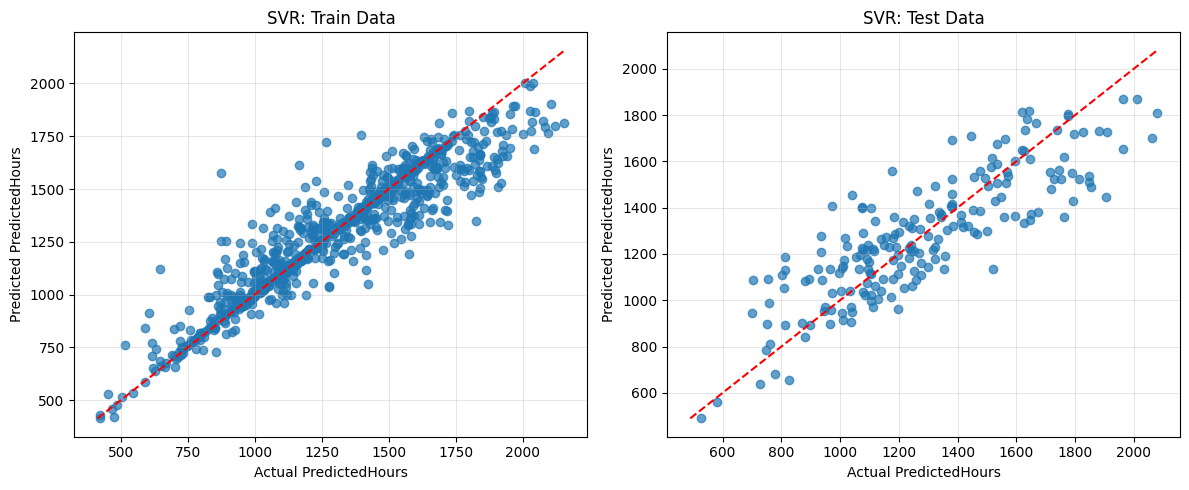

In [102]:
# 訓練データとテストデータのグラフを横に並べて表示します。
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 訓練データの実際の材料寿命と予測値を点で描きます。
axes[0].scatter(material_y_train, material_y_train_pred, alpha=0.7)

# 訓練データで、実際の値と予測値が一致する基準線を描きます。
material_train_min_value = min(material_y_train.min(), material_y_train_pred.min())
material_train_max_value = max(material_y_train.max(), material_y_train_pred.max())
axes[0].plot([material_train_min_value, material_train_max_value], [material_train_min_value, material_train_max_value], color="red", linestyle="--")

# 訓練データのグラフタイトルと軸ラベルを設定します。
axes[0].set_title("SVR: Train Data")
axes[0].set_xlabel("Actual PredictedHours")
axes[0].set_ylabel("Predicted PredictedHours")
axes[0].grid(True, alpha=0.3)

# テストデータの実際の材料寿命と予測値を点で描きます。
axes[1].scatter(material_y_test, material_y_pred, alpha=0.7)

# テストデータで、実際の値と予測値が一致する基準線を描きます。
material_test_min_value = min(material_y_test.min(), material_y_pred.min())
material_test_max_value = max(material_y_test.max(), material_y_pred.max())
axes[1].plot([material_test_min_value, material_test_max_value], [material_test_min_value, material_test_max_value], color="red", linestyle="--")

# テストデータのグラフタイトルと軸ラベルを設定します。
axes[1].set_title("SVR: Test Data")
axes[1].set_xlabel("Actual PredictedHours")
axes[1].set_ylabel("Predicted PredictedHours")
axes[1].grid(True, alpha=0.3)

# グラフ同士が重ならないように間隔を調整します。
plt.tight_layout()

# グラフを表示します。
plt.show()

## 10. モデルの性能を確認する

`R2` は1に近いほど良く、`RMSE` と `MAE` は小さいほど予測誤差が小さいことを表します。

In [103]:
# R2を計算します。1に近いほど、モデルの当てはまりが良いです。
material_r2 = r2_score(material_y_test, material_y_pred)

# RMSEを計算します。予測のずれの大きさを表し、小さいほど良いです。
material_rmse = np.sqrt(mean_squared_error(material_y_test, material_y_pred))

# MAEを計算します。平均でどれくらい予測が外れたかを表します。
material_mae = mean_absolute_error(material_y_test, material_y_pred)

# R2を表示します。
print("R2:", material_r2)

# RMSEを表示します。
print("RMSE:", material_rmse)

# MAEを表示します。
print("MAE:", material_mae)

R2: 0.7125553122486115
RMSE: 172.50365179023942
MAE: 136.47567328500415
